# 04 — Analyze results

Compare baseline and advanced runs from `outputs/runs/`.

Load the master registry or scan run directories directly.


In [1]:
import sys
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
REPO = ROOT if (ROOT / "src").is_dir() else ROOT.parent
sys.path.insert(0, str(REPO))

from src.config import get_config
from src.experiments import run_experiment, run_experiments, results_to_dataframe, RunExistsError
from src.experiments.results import load_registry, load_all_runs
from src.experiments.run_manager import RunManager
from src.utils import setup_logging

setup_logging()
cfg = get_config()
runs_root = cfg.repo_root / "outputs" / "runs"

import matplotlib.pyplot as plt
import numpy as np


## Load experiment registry


In [2]:
registry_path = runs_root / "experiments.csv"
registry = load_registry(registry_path)
all_runs = load_all_runs(runs_root)

# Prefer registry; fall back to scanning run dirs
summary = registry if len(registry) else all_runs
summary


,run_name,timestamp,pipeline,method,split,perspective,mae_mm,rmse_mm,n_samples,predictions_path,comparison_path,run_dir
0,test_validation_only,2026-05-30T21:35:36.247387Z,baseline,bbox,valid,False,632.496441,692.126886,30,/Users/sebastianinouye/Desktop/Everything/Proj...,/Users/sebastianinouye/Desktop/Everything/Proj...,/Users/sebastianinouye/Desktop/Everything/Proj...
1,baseline_pca_v1,2026-05-30T23:50:27.772613Z,baseline,pca,valid,False,625.787897,673.010863,30,/Users/sebastianinouye/Desktop/Everything/Proj...,/Users/sebastianinouye/Desktop/Everything/Proj...,/Users/sebastianinouye/Desktop/Everything/Proj...
2,baseline_bbox_v1,2026-05-30T23:53:15.542015Z,baseline,bbox,valid,False,632.496441,692.126886,30,/Users/sebastianinouye/Desktop/Everything/Proj...,/Users/sebastianinouye/Desktop/Everything/Proj...,/Users/sebastianinouye/Desktop/Everything/Proj...
3,baseline_pca_v1,2026-05-30T23:53:21.193466Z,baseline,pca,valid,False,625.787897,673.010863,30,/Users/sebastianinouye/Desktop/Everything/Proj...,/Users/sebastianinouye/Desktop/Everything/Proj...,/Users/sebastianinouye/Desktop/Everything/Proj...
4,baseline_skeleton_v1,2026-05-30T23:54:31.246133Z,baseline,skeleton,valid,False,99164.487296,129982.999146,30,/Users/sebastianinouye/Desktop/Everything/Proj...,/Users/sebastianinouye/Desktop/Everything/Proj...,/Users/sebastianinouye/Desktop/Everything/Proj...


## Compare MAE / RMSE across runs


In [3]:
if len(summary):
    cols = ["run_name", "pipeline", "method", "perspective", "mae_mm", "rmse_mm", "n_samples"]
    display_cols = [c for c in cols if c in summary.columns]
    summary[display_cols].sort_values("mae_mm")
else:
    print("No runs yet — run 03_run_experiments.ipynb first")


## Bar chart: baseline vs advanced


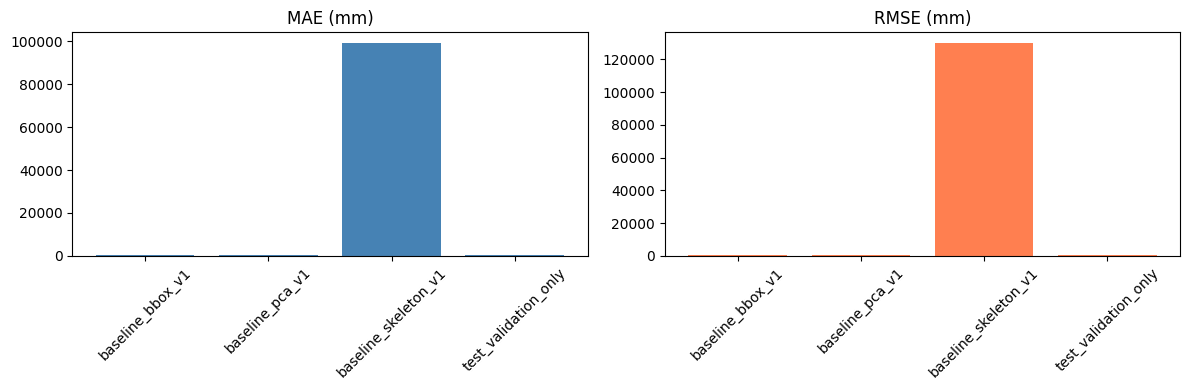

In [4]:
if len(summary) and "mae_mm" in summary.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_df = summary.dropna(subset=["mae_mm"]).sort_values("run_name")
    axes[0].bar(plot_df["run_name"], plot_df["mae_mm"], color="steelblue")
    axes[0].set_title("MAE (mm)")
    axes[0].tick_params(axis="x", rotation=45)
    axes[1].bar(plot_df["run_name"], plot_df["rmse_mm"], color="coral")
    axes[1].set_title("RMSE (mm)")
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


## Per-image errors from comparison.csv


,image_id,length_mm,predicted_length_mm,error_mm,abs_error_mm
0,10786,39.0,457.446971,418.446971,418.446971
1,11050,82.0,818.018431,736.018431,736.018431
2,12288,69.0,683.824978,614.824978,614.824978
3,12719,41.0,392.455714,351.455714,351.455714
4,12797,80.0,788.576825,708.576825,708.576825
5,13736,73.0,706.178994,633.178994,633.178994
6,14227,58.0,570.025883,512.025883,512.025883
7,1491,36.0,370.840509,334.840509,334.840509
8,15157,42.0,503.821713,461.821713,461.821713
9,15199,57.0,565.307917,508.307917,508.307917


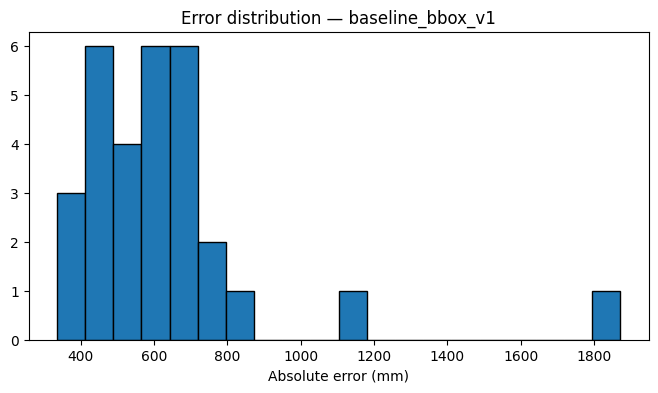

In [5]:
RUN_TO_INSPECT = "baseline_bbox_v1"  # change as needed
run_dir = runs_root / RUN_TO_INSPECT
comparison_path = run_dir / "comparison.csv"

if comparison_path.is_file():
    errors = pd.read_csv(comparison_path)
    display(errors.head(10))
    if "abs_error_mm" in errors.columns:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(errors["abs_error_mm"].dropna(), bins=20, edgecolor="k")
        ax.set_xlabel("Absolute error (mm)")
        ax.set_title(f"Error distribution — {RUN_TO_INSPECT}")
        plt.show()
else:
    print(f"No comparison at {comparison_path}")


## Side-by-side metric table (baseline vs advanced)


In [6]:
if len(summary):
    pivot = summary.pivot_table(
        index="method",
        columns="pipeline",
        values="mae_mm",
        aggfunc="min",
    )
    pivot
